# GATE software week 1 - Shapes and volumes

You will need to look at the GATE software documentation at https://opengate-python.readthedocs.io/en/10.0.2/index.html

#### Import all the packages that you will need for the simulation
1. Opengate is the GATE simulation software.
2. Pyvista helps you to visualise your simulation.
3. NumPy helps is to work with lists of numbers and perform mathematical operations.
4. os. and Pathlib allow us to define the 'path' to the location of files that we want to use in our Google Drive folder.

In [1]:
import opengate as gate
#!apt-get install -qq xvfb libgl1-mesa-glx
#!pip install pyvista -qq
import pyvista as pv
pv.set_jupyter_backend('static')
pv.global_theme.notebook = True
pv.start_xvfb()
#pv.set_jupyter_backend('html')
import numpy as np
import os
import pathlib
from pathlib import Path

This function is deprecated and will be removed in future version of PyVista. Use vtk-osmesa instead.


#### Define your units

In [2]:
m = gate.g4_units.m
cm = gate.g4_units.cm
mm = gate.g4_units.mm
um = gate.g4_units.um
deg = gate.g4_units.deg

#### And your colours
- These are defined by 4 numbers: [RED, GREEN, BLUE, transparency]
- You can only use colours that you define in this list.
- Try to create your own colours and add them to the list :-)

In [3]:
# Define colours
colours = {
 'cyan': [0, 1, 1, 1],
 'grey': [.7, .7, .7, 0.03],
 'yellow': [1, 1, 0, 1],
 'green': [0, 1, 0, 1], 
 'blue': [0, 0, 1, 1]   
}

## Volumes
Must be defined with:
- type
- name
- size
- mother volume
- position - if no position is specified, volume is positioned at the centre of it's 'mother' volume
- material (from GEANT 4 materials database)
- colour

You first need to initialise your simulation.

In [4]:
sim = gate.Simulation()
sim.visu = True             # To display the simulation
sim.visu_type = 'vrml'

You can get more information about volume commands by running 'help(sim.volume_manager).  
(It generates a long output so use 'Clear cell output' to hide it!) 

In [ ]:
help(sim.volume_manager)

Define the world as a 2 m x 2 m x 2 m cube (air)  
Available materials can be found at:  
https://geant4-userdoc.web.cern.ch/UsersGuides/ForApplicationDeveloper/html/Appendix/materialNames.html

In [8]:
world = sim.world
sim.world.size = [5 * m, 5 * m, 5 * m]
sim.world.material = 'G4_AIR'
sim.world.color = colours['grey']

Dispatching simulation to subprocess ...
⚠️ No configured source, no particle will be generated.
Simulation: create RunManager (single thread)
Simulation: initialize Geometry
Simulation: initialize Physics
Simulation: initialize Source
Simulation: initialize Visualization
Simulation: initialize G4RunManager
Simulation: initialize PhysicsEngine after RunManager initialization
Simulation: initialize actors
Simulation: check volumes overlap
--------------------------------------------------------------------------------
Simulation: START (in a new process) 
Simulation: STOP. Run: 1. Time: 0.2 seconds.
--------------------------------------------------------------------------------


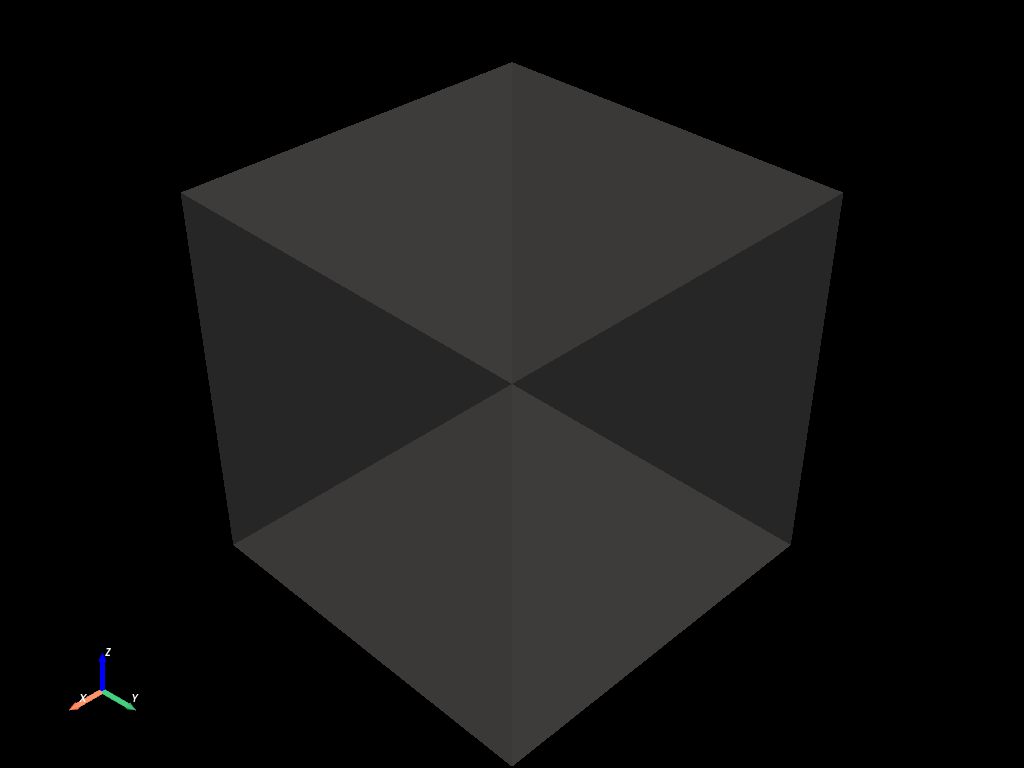

⚠️ One warning occurred in this simulation:
⚠️ (1) No configured source, no particle will be generated.


In [9]:
sim.run(start_new_process=True)  # This allows us to run the simulation multiple times in the same notebook

Create a water-filled cylinder.
- Name: 'cylinder'
- Size: radius 10.8 cm and length 18.6 cm
- Mother volume: 'world' (your box of air!)
- Position: at the centre of the world.
- Material: water
- Colour: cyan (this is light blue!)

In [10]:
cylinder_vol = sim.add_volume('TubsVolume', 'cylinder')
cylinder_vol.rmin = 0 * cm                                             # This is your inner radius (should be 0 for a 'full cylinder)                                
cylinder_vol.rmax = 10.8 * cm                                          # Outer radius
cylinder_vol.dz = 18.6 * cm / 2.0                                      # dz is half-height (full height is 18.6 cm)               
cylinder_vol.material = 'G4_WATER'
cylinder_vol.color =  colours['cyan']
cylinder_vol.mother = 'world'

In [11]:
pv.set_jupyter_backend('html')     # This allows you to zoom in and out!
sim.run(start_new_process=True)

Dispatching simulation to subprocess ...
⚠️ No configured source, no particle will be generated.
Simulation: create RunManager (single thread)
Simulation: initialize Geometry
Simulation: initialize Physics
Simulation: initialize Source
Simulation: initialize Visualization
Simulation: initialize G4RunManager
Simulation: initialize PhysicsEngine after RunManager initialization
Simulation: initialize actors
Simulation: check volumes overlap
--------------------------------------------------------------------------------
Simulation: START (in a new process) 
Simulation: STOP. Run: 1. Time: 0.2 seconds.
--------------------------------------------------------------------------------


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

⚠️ 2 warnings occurred in this simulation:
⚠️ (1) No configured source, no particle will be generated.
⚠️ (2) No configured source, no particle will be generated.


Add a plexi-glass (plastic) shell around the outside of the cylinder to contain all the water.  
- Name: 'cylindershell'
- Size: 3.2 mm thick surrounding the water
- Mother volume: 'world'
- Position: at the centre of the world (surrounding the water).
- Material: plexiglass
- Colour: green

In [12]:
shell = sim.add_volume('TubsVolume', 'cylindershell')
shell.rmin = 10.8 * cm                      # the inner radius (edge of water)
shell.rmax = 11.12 * cm                     # PMMA thickness 3.2 mm --> radius is 10.8 + 0.32 cm
shell.dz = 18.92 * cm / 2.0                 # Length is 18.6 + 0.32 cm = 18.92 cm               
shell.material = 'G4_PLEXIGLASS'
shell.color =  colours['green']
shell.mother = 'world'

Can you run the simulation again?

In [13]:
sim.run(start_new_process=True)

Dispatching simulation to subprocess ...
⚠️ No configured source, no particle will be generated.
Simulation: create RunManager (single thread)
Simulation: initialize Geometry
Simulation: initialize Physics
Simulation: initialize Source
Simulation: initialize Visualization
Simulation: initialize G4RunManager
Simulation: initialize PhysicsEngine after RunManager initialization
Simulation: initialize actors
Simulation: check volumes overlap
--------------------------------------------------------------------------------
Simulation: START (in a new process) 
Simulation: STOP. Run: 1. Time: 0.2 seconds.
--------------------------------------------------------------------------------


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

⚠️ 3 warnings occurred in this simulation:
⚠️ (1) No configured source, no particle will be generated.
⚠️ (2) No configured source, no particle will be generated.
⚠️ (3) No configured source, no particle will be generated.


Can you make another water-filled cylinder, positioned at 50 cm away from 'cylinder_vol?'
- Name: 'cylinder2'
- Size: radius 10.8 cm and length 18.6 cm
- Mother volume: 'world' 
- Position: 50 cm in the 'x' direction
- Material: water
- Colour: cyan  

Shell:
- Size: 3.2 mm thick surrounding the water
- Mother volume: 'world'
- Position: 50 cm in the 'x' direction
- Material: plexiglass
- Colour: green

In [14]:
cylinder_vol_2 = sim.add_volume('TubsVolume', 'cylinder2')
cylinder_vol_2.rmin = 0 * cm                                             # This is your inner radius (should be 0 for a 'full cylinder)                                
cylinder_vol_2.rmax = 10.8 * cm                                          # Outer radius
cylinder_vol_2.dz = 18.6 * cm / 2.0                                      # dz is half-height (full height is 18.6 cm)
#cylinder_vol.rotation = np.array([[1, 0, 0], [0, 0, -1], [0, 1, 0]])    # rotation by 90 deg in x-axis to align with gantry axis
cylinder_vol_2.translation = [50 * cm, 0 * cm, 0 * cm]                   # translate by 50 cm from the centre of the WORLD          
cylinder_vol_2.material = 'G4_WATER'
cylinder_vol_2.color =  colours['cyan']
cylinder_vol_2.mother = 'world'

# The shell must also move in the same direction

shell_2 = sim.add_volume('TubsVolume', 'cylindershell2')
shell_2.rmin = 10.8 * cm                      # the inner radius (edge of water)
shell_2.rmax = 11.12 * cm                     # PMMA thickness 3.2 mm --> radius is 10.8 + 0.32 cm
shell_2.dz = 18.92 * cm / 2.0                 # Length is 18.6 + 0.32 cm = 18.92 cm   
shell_2.translation = [50 * cm, 0 * cm, 0 * cm]                  
shell_2.material = 'G4_PLEXIGLASS'
shell_2.color =  colours['green']
shell_2.mother = 'world'

In [15]:
sim.run(start_new_process=True)

Dispatching simulation to subprocess ...
⚠️ No configured source, no particle will be generated.
Simulation: create RunManager (single thread)
Simulation: initialize Geometry
Simulation: initialize Physics
Simulation: initialize Source
Simulation: initialize Visualization
Simulation: initialize G4RunManager
Simulation: initialize PhysicsEngine after RunManager initialization
Simulation: initialize actors
Simulation: check volumes overlap
--------------------------------------------------------------------------------
Simulation: START (in a new process) 
Simulation: STOP. Run: 1. Time: 0.2 seconds.
--------------------------------------------------------------------------------


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

⚠️ 4 warnings occurred in this simulation:
⚠️ (1) No configured source, no particle will be generated.
⚠️ (2) No configured source, no particle will be generated.
⚠️ (3) No configured source, no particle will be generated.
⚠️ (4) No configured source, no particle will be generated.


Can you make another water-filled cylinder, positioned at -50 cm away from the original cylinder in the x-direction and 20 cm in the y-direction?  
Can you rotate it by 90 degrees in the x-direction?  

Rotation matrix:  
- [[1, 0, 0], [0, 0, -1], [0, 1, 0]] 90 degrees in x-direction

- [[0, 0, 1], [0, 1, 0], [-1, 0, 0]] 90 degrees in y-direction

- [[0, -1, 0], [1, 0, 0], [0, 0, 1]] 90 degrees in z-direction

In [16]:
cylinder_vol_3 = sim.add_volume('TubsVolume', 'cylinder3')
cylinder_vol_3.rmin = 0 * cm                                             # This is your inner radius (should be 0 for a 'full cylinder)                                
cylinder_vol_3.rmax = 10.8 * cm                                          # Outer radius
cylinder_vol_3.dz = 18.6 * cm / 2.0                                      # dz is half-height (full height is 18.6 cm)
cylinder_vol_3.translation = [-50 * cm, 20 * cm, 0 * cm]                  # translate by 50 cm along the x-axis and +20 cm along the y-axis   
cylinder_vol_3.rotation = np.array([[1, 0, 0], [0, 0, -1], [0, 1, 0]])   # rotation by 90 deg in the x-direction
cylinder_vol_3.material = 'G4_WATER'
cylinder_vol_3.color =  colours['cyan']
cylinder_vol_3.mother = 'world'

# The shell must also move and rotate in the same direction

shell_3 = sim.add_volume('TubsVolume', 'cylindershell3')
shell_3.rmin = 10.8 * cm                     
shell_3.rmax = 11.12 * cm                     
shell_3.dz = 18.92 * cm / 2.0                  
shell_3.translation = [-50 * cm, 20 * cm, 0 * cm]                                     
shell_3.rotation = np.array([[1, 0, 0], [0, 0, -1], [0, 1, 0]])  
shell_3.material = 'G4_PLEXIGLASS'
shell_3.color =  colours['green']
shell_3.mother = 'world'

In [17]:
sim.run(start_new_process=True)

Dispatching simulation to subprocess ...
⚠️ No configured source, no particle will be generated.
Simulation: create RunManager (single thread)
Simulation: initialize Geometry
Simulation: initialize Physics
Simulation: initialize Source
Simulation: initialize Visualization
Simulation: initialize G4RunManager
Simulation: initialize PhysicsEngine after RunManager initialization
Simulation: initialize actors
Simulation: check volumes overlap
--------------------------------------------------------------------------------
Simulation: START (in a new process) 
Simulation: STOP. Run: 1. Time: 0.2 seconds.
--------------------------------------------------------------------------------


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

⚠️ 5 warnings occurred in this simulation:
⚠️ (1) No configured source, no particle will be generated.
⚠️ (2) No configured source, no particle will be generated.
⚠️ (3) No configured source, no particle will be generated.
⚠️ (4) No configured source, no particle will be generated.
⚠️ (5) No configured source, no particle will be generated.


Next we want to import a camera model.. the GE Discovery is already programmmed into GATE so we can import that first and see what it looks like!

In [18]:
import opengate.contrib.spect.ge_discovery_nm670 as discovery

Gate can't cope with volumes that overlap each other. So we add a 'parallel world' which is the same size, shape and position as the world that the water cylinders live in.

In [19]:
sim.add_parallel_world('parallel world')

In [ ]:
spect, collimator, crystal = discovery.add_spect_head(sim, 
                                                      name = 'discovery1', 
                                                      collimator_type = False,    # it takes a long time to visualise!!
                                                      rotation_deg = 0,
                                                      crystal_size = '3/8')

spect.mother = 'parallel world'
#discovery.add_digitizer_tc99m(sim, crystal.name, 'digit_tc99m')

#spect = discovery.add_spect_head(sim, "discovery12", collimator_type="lehr")
#crystal = sim.volume_manager.get_volume(f"{spect.name}_crystal")
#discovery.add_digitizer_lu177(sim, crystal.name, "digit_lu177", rotation_deg=15, crystal_size="5/8")

In [ ]:
sim.run(start_new_process=True)

It looks like our SPECT detector is crashing into our water cylinder!  
You can reset the simulation using sim.volume_manager.reset().  
Then you could start again, moving the detector 20 cm away in the y-direction.

In [39]:
sim.volume_manager.reset()

In [ ]:
sim.volume_manager.print_volumes()

In [ ]:
sim.volume_manager.remove_volume('parallel world')

In [ ]:
help(sim.volume_manager)

In [ ]:
sim.volume_manager.d

In [ ]:
sim.run(start_new_process=True)

In [ ]:
help(sim)